# B7 – Forecasting: NARDL vs Machine Learning

**Train:** 2015-01 → 2022-12 | **Test:** 2023-01 → 2025-12

**Pipeline:**
1. Load & rebuild DatetimeIndex từ data_processed (index saved without name)
2. ARDL/NARDL Recursive Forecast (OLS via scipy)
3. ML Forecast: Random Forest, Gradient Boosting, SVR
4. Metrics (RMSE, MAE, MAPE) + Plots

In [28]:
import pandas as pd
import numpy as np
import os, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.cm as cm

from scipy.linalg import lstsq

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data & Fix Index

In [29]:
DATA_FILE = '../data/processed/data_processed.csv'
OUT_DIR   = '../results/forecast'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Đọc file – index được lưu không có tên (index=False trong processing) ──
raw = pd.read_csv(DATA_FILE)
print('Columns:', list(raw.columns))
print('Shape  :', raw.shape)
print('First row:\n', raw.head(2))

Columns: ['ln_FDI', 'ln_TB', 'ln_EX', 'ln_IM', 'ln_RER_pos', 'ln_RER_neg', 'IPI_VN', 'IPI_World_diff', 'ln_WTI', 'ln_M2_diff', 'COVID']
Shape  : (132, 11)
First row:
      ln_FDI     ln_TB      ln_EX      ln_IM  ln_RER_pos  ln_RER_neg  \
0  0.008915  0.056151  16.664659  16.608507         0.0    0.000000   
1  0.031377 -0.020926  16.308444  16.329370         0.0    0.006208   

       IPI_VN  IPI_World_diff    ln_WTI  ln_M2_diff  COVID  
0  100.000000             NaN  3.854818         NaN      0  
1   90.472674             NaN  3.923556    0.001426      0  


In [30]:
# ── Rebuild DatetimeIndex ─────────────────────────────────────────────────
#
# data_processing.ipynb dùng:
#   data_processed.to_csv(..., index=False)
# → Period index bị DROP hoàn toàn. File CSV chỉ còn 11 cột số,
#   không có cột date nào. Pandas đọc lại sẽ gán RangeIndex (0,1,2,...).
#
# Fix: tái tạo DatetimeIndex từ đầu dựa vào:
#   - Biết data bắt đầu 2015-01 (từ data_processing)
#   - Số hàng = len(raw)
#   - Tần suất = monthly (MS = month start)
# ────────────────────────────────────────────────────────────────────────────

data = raw.copy()

# Kiểm tra xem cột đầu có parse được thành date không
# (phòng trường hợp ai đó đã lưu lại với index=True)
first_col = raw.columns[0]
col_as_date = None
try:
    parsed = pd.to_datetime(raw[first_col], errors='raise')
    # Chỉ chấp nhận nếu range hợp lý (sau 2010)
    if parsed.min().year >= 2010:
        col_as_date = parsed
        print(f'✓ Cột "{first_col}" là date → dùng làm index')
except Exception:
    pass

if col_as_date is not None:
    data.index = col_as_date
    data = data.drop(columns=[first_col])
else:
    # index=False đã drop Period → rebuild từ shape
    n_rows = len(raw)
    # Data bắt đầu 2015-01 theo data_processing.ipynb
    DATA_START = '2015-01-01'
    new_idx = pd.date_range(start=DATA_START, periods=n_rows, freq='MS')
    data.index = new_idx
    print(f'✓ index=False đã drop Period → rebuild: {DATA_START} + {n_rows} tháng')

data.index.name = 'date'
data = data.sort_index()

# Verify
print(f'Index range : {data.index[0].strftime("%Y-%m")} → {data.index[-1].strftime("%Y-%m")}')
print(f'Total obs   : {len(data)}')
print(f'Columns     : {list(data.columns)}')
data.head(3)

✓ index=False đã drop Period → rebuild: 2015-01-01 + 132 tháng
Index range : 2015-01 → 2025-12
Total obs   : 132
Columns     : ['ln_FDI', 'ln_TB', 'ln_EX', 'ln_IM', 'ln_RER_pos', 'ln_RER_neg', 'IPI_VN', 'IPI_World_diff', 'ln_WTI', 'ln_M2_diff', 'COVID']


,ln_FDI,ln_TB,ln_EX,ln_IM,ln_RER_pos,ln_RER_neg,IPI_VN,IPI_World_diff,ln_WTI,ln_M2_diff,COVID
date,,,,,,,,,,,
2015-01-01,0.008915,0.056151,16.664659,16.608507,0.000000,0.000000,100.000000,NaN,3.854818,NaN,0
2015-02-01,0.031377,-0.020926,16.308444,16.329370,0.000000,0.006208,90.472674,NaN,3.923556,0.001426,0
2015-03-01,0.009129,-0.040911,16.643582,16.684493,0.000626,0.000000,94.531437,0.040182,3.867444,-0.000088,0


## 2. Train/Test Split & Model Specs

In [31]:
# ── Train/Test boundaries ─────────────────────────────────────────────────
TRAIN_START = '2015-01-01'
TRAIN_END   = '2022-12-01'
TEST_START  = '2023-01-01'

# Dùng boolean mask (an toàn, không phụ thuộc vào label slicing)
mask_train = (data.index >= TRAIN_START) & (data.index <= TRAIN_END)
mask_test  = data.index >= TEST_START

n_train = mask_train.sum()
n_test  = mask_test.sum()

print(f'Train: {n_train} obs  ({TRAIN_START[:7]} → {TRAIN_END[:7]})')
if n_test > 0:
    print(f'Test : {n_test} obs  ({TEST_START[:7]} → {data.index[mask_test][-1].strftime("%Y-%m")})')
else:
    print('⚠️  Không có dữ liệu sau 2023-01 trong file.')
    print('   → Dùng 24 tháng cuối làm pseudo-test set.')
    n_pseudo   = min(24, len(data) // 4)
    all_idx    = np.arange(len(data))
    mask_train = all_idx < (len(data) - n_pseudo)
    mask_test  = all_idx >= (len(data) - n_pseudo)
    mask_train = pd.Series(mask_train, index=data.index).values.astype(bool)
    mask_test  = pd.Series(mask_test,  index=data.index).values.astype(bool)
    print(f'   Pseudo-train: {mask_train.sum()} | Pseudo-test: {mask_test.sum()}')

Train: 96 obs  (2015-01 → 2022-12)
Test : 36 obs  (2023-01 → 2025-12)


In [32]:
# ── Model specs từ B4 ─────────────────────────────────────────────────────
# ln_RER_pos / ln_RER_neg trong data_processing là INSTANTANEOUS shocks
# (bước nhảy dương/âm của Δln_RER), không phải cumulative partial sums.
# Điều này vẫn hợp lệ cho ARDL – các lag của chúng capture dynamic effects.

MODELS = {
    'EX': {
        'dep'      : 'ln_EX',
        'exog'     : ['ln_RER_pos','ln_RER_neg','ln_FDI','IPI_VN',
                      'IPI_World_diff','ln_M2_diff','ln_WTI','COVID'],
        'lag_dep'  : 6,
        'lag_exog' : [3, 1, 6, 6, 5, 2, 0]
    },
    'IM': {
        'dep'      : 'ln_IM',
        'exog'     : ['ln_RER_pos','ln_RER_neg','ln_FDI','IPI_VN',
                      'IPI_World_diff','ln_M2_diff','ln_WTI','COVID'],
        'lag_dep'  : 3,
        'lag_exog' : [3, 1, 2, 2, 4, 3, 0]
    }
}

# Verify all variables exist
for key, spec in MODELS.items():
    missing = [v for v in spec['exog'] if v not in data.columns]
    present = [v for v in spec['exog'] if v in data.columns]
    print(f'{key}: dep={spec["dep"]}  exog_found={len(present)}  missing={missing}')

EX: dep=ln_EX  exog_found=8  missing=[]
IM: dep=ln_IM  exog_found=8  missing=[]


## 3. Helper Functions

In [33]:
def add_lags(df, var_list, lag_list):
    """Add lagged columns to df. Returns copy."""
    out = df.copy()
    for var, lag in zip(var_list, lag_list):
        if lag > 0 and var in out.columns:
            for l in range(1, lag + 1):
                out[f'{var}_L{l}'] = out[var].shift(l)
    return out


def prepare_ardl_data(df, dep, exog_vars, lag_dep, lag_exog):
    """Build (y, X, feature_names, clean_index) for ARDL OLS."""
    work = df[[dep] + exog_vars].copy()
    work = add_lags(work, exog_vars, lag_exog)

    # Lagged dependent variable
    for l in range(1, lag_dep + 1):
        work[f'{dep}_L{l}'] = work[dep].shift(l)

    work = work.dropna()

    exog_lag_cols = [c for c in work.columns
                     if c != dep and c not in exog_vars]
    feat_cols = exog_lag_cols  # all lagged cols (dep lags + exog lags)

    y = work[dep].values
    X = np.column_stack([np.ones(len(y)), work[feat_cols].values])
    feat_names = ['const'] + feat_cols
    return y, X, feat_names, work.index, work


def ols_fit(y, X):
    coef, _, _, _ = lstsq(X, y)
    fitted = X @ coef
    resid  = y - fitted
    ss_res = float(np.sum(resid**2))
    ss_tot = float(np.sum((y - y.mean())**2))
    r2     = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
    return coef, fitted, resid, r2


def compute_metrics(actual, predicted, label=''):
    a, p = np.array(actual), np.array(predicted)
    rmse = float(np.sqrt(mean_squared_error(a, p)))
    mae  = float(mean_absolute_error(a, p))
    mask = a != 0
    mape = float(np.mean(np.abs((a[mask]-p[mask])/a[mask]))*100) if mask.any() else np.nan
    if label:
        print(f'  {label:28s}  RMSE={rmse:.5f}  MAE={mae:.5f}  MAPE={mape:.2f}%')
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


print('Helpers defined ✓')

Helpers defined ✓


## 4. ARDL/NARDL Recursive Forecast

In [34]:
ardl_results = {}

for model_key, spec in MODELS.items():
    dep       = spec['dep']
    exog_vars = [v for v in spec['exog'] if v in data.columns]
    lag_dep   = spec['lag_dep']
    lag_exog  = spec['lag_exog'][:len(exog_vars)]

    print(f'\n── ARDL: {model_key} ({dep}) ──')

    # ── Build full lagged dataset (no slicing by label – use mask) ──────────
    work_full  = add_lags(data[exog_vars + [dep]].copy(), exog_vars, lag_exog)
    for l in range(1, lag_dep + 1):
        work_full[f'{dep}_L{l}'] = work_full[dep].shift(l)
    work_full = work_full.dropna()

    exog_lag_cols = [c for c in work_full.columns
                     if c != dep and c not in exog_vars]
    feat_names = ['const'] + exog_lag_cols

    # ── Positional masks after dropna ──────────────────────────────────────
    idx_arr   = work_full.index
    tr_mask   = (idx_arr >= TRAIN_START) & (idx_arr <= TRAIN_END)
    te_mask   = idx_arr >= TEST_START

    # Fallback if no test rows
    if te_mask.sum() == 0:
        n_back  = min(24, len(idx_arr)//4)
        tr_mask = np.ones(len(idx_arr), dtype=bool)
        tr_mask[-n_back:] = False
        te_mask = ~tr_mask
        print(f'  ⚠️  Fallback: last {n_back} obs as test')

    df_tr = work_full[tr_mask]
    df_te = work_full[te_mask]
    print(f'  Train: {len(df_tr)} obs | Test: {len(df_te)} obs')

    # ── OLS on train ────────────────────────────────────────────────────────
    y_tr = df_tr[dep].values
    X_tr = np.column_stack([np.ones(len(y_tr)), df_tr[exog_lag_cols].values])
    coef, fitted_tr, resid_tr, r2 = ols_fit(y_tr, X_tr)
    print(f'  R²_train = {r2:.4f}')

    # ── Recursive forecast on test ──────────────────────────────────────────
    # Concatenate train + test for accessing lagged exog
    df_all    = pd.concat([df_tr, df_te])
    n_tr_all  = len(df_tr)
    dep_vals  = list(df_all[dep].values)   # ground-truth dep (for lag lookup)

    y_pred = []
    for step in range(len(df_te)):
        pos = n_tr_all + step    # absolute position in df_all

        x_row = [1.0]            # const

        for feat in exog_lag_cols:
            if feat.startswith(dep + '_L'):
                # Lagged dependent: use predicted if beyond training
                l = int(feat.split('_L')[1])
                src_pos = pos - l
                if src_pos < 0:
                    x_row.append(0.0)
                elif src_pos < n_tr_all:
                    # Within training – use actual
                    x_row.append(dep_vals[src_pos])
                else:
                    # Within test – use prior prediction
                    pred_offset = src_pos - n_tr_all
                    x_row.append(y_pred[pred_offset]
                                 if pred_offset < len(y_pred)
                                 else dep_vals[src_pos])
            else:
                # Lagged exog: actual value already in the lagged column
                col_vals = df_all[feat].values
                x_row.append(float(col_vals[pos])
                              if not np.isnan(col_vals[pos]) else 0.0)

        x_vec = np.array(x_row)
        y_hat = float(coef @ x_vec)
        y_pred.append(y_hat)

    y_actual = df_te[dep].values[:len(y_pred)]
    idx_te   = df_te.index[:len(y_pred)]
    m = compute_metrics(y_actual, y_pred, label=f'ARDL {model_key}')

    ardl_results[model_key] = {
        'dep': dep, 'coef': dict(zip(feat_names, coef)),
        'fitted_train': fitted_tr, 'idx_train': df_tr.index, 'y_train': y_tr,
        'y_pred_test': np.array(y_pred), 'y_actual_test': y_actual,
        'idx_test': idx_te, 'metrics': m, 'R2_train': r2,
        'resid_train': resid_tr
    }

print('\n✓ ARDL forecast complete')


── ARDL: EX (ln_EX) ──
  Train: 89 obs | Test: 36 obs
  R²_train = 0.8812
  ARDL EX                       RMSE=0.45536  MAE=0.39652  MAPE=2.26%

── ARDL: IM (ln_IM) ──
  Train: 90 obs | Test: 36 obs
  R²_train = 0.8977
  ARDL IM                       RMSE=0.38035  MAE=0.32001  MAPE=1.83%

✓ ARDL forecast complete


## 5. Machine Learning Forecast

In [35]:
ML_ESTIMATORS = {
    'Random Forest' : RandomForestRegressor(
                        n_estimators=300, max_depth=8,
                        min_samples_leaf=3, random_state=42, n_jobs=-1),
    'Gradient Boost': GradientBoostingRegressor(
                        n_estimators=300, max_depth=4,
                        learning_rate=0.05, subsample=0.8, random_state=42),
    'SVR'           : Pipeline([
                        ('sc',  StandardScaler()),
                        ('svr', SVR(kernel='rbf', C=10, epsilon=0.01, gamma='scale'))
                      ])
}


def build_ml_matrix(df, dep, exog_vars, lag_dep, lag_exog):
    """Build flat ML feature matrix. All features are lag-safe (no leakage)."""
    feat = df[[dep] + exog_vars].copy()
    # Lagged dep
    for l in range(1, lag_dep + 1):
        feat[f'{dep}_L{l}'] = feat[dep].shift(l)
    # Rolling stats (shift(1) ensures no leakage)
    feat[f'{dep}_roll3'] = feat[dep].shift(1).rolling(3).mean()
    feat[f'{dep}_roll6'] = feat[dep].shift(1).rolling(6).mean()
    feat[f'{dep}_diff1'] = feat[dep].diff(1).shift(1)
    # Lagged exog
    feat = add_lags(feat, exog_vars, lag_exog)
    feat = feat.dropna()
    fcols = [c for c in feat.columns if c != dep]
    return feat[dep], feat[fcols], feat.index, fcols


ml_results = {}

for model_key, spec in MODELS.items():
    dep       = spec['dep']
    exog_vars = [v for v in spec['exog'] if v in data.columns]
    lag_dep   = spec['lag_dep']
    lag_exog  = spec['lag_exog'][:len(exog_vars)]

    print(f'\n── ML: {model_key} ({dep}) ──')

    y_all, X_all, idx_all, feat_cols = build_ml_matrix(
        data, dep, exog_vars, lag_dep, lag_exog)

    # Positional masks
    tr_mask = (idx_all >= TRAIN_START) & (idx_all <= TRAIN_END)
    te_mask = idx_all >= TEST_START
    if te_mask.sum() == 0:
        n_back  = min(24, len(idx_all)//4)
        tr_mask = np.ones(len(idx_all), dtype=bool)
        tr_mask[-n_back:] = False
        te_mask = ~tr_mask

    X_tr, y_tr = X_all[tr_mask].values, y_all[tr_mask].values
    X_te, y_te = X_all[te_mask].values, y_all[te_mask].values
    idx_te = idx_all[te_mask]
    print(f'  Train: {len(y_tr)} | Test: {len(y_te)}')

    preds, metrics_dict = {}, {}
    for name, est in ML_ESTIMATORS.items():
        est.fit(X_tr, y_tr)
        yp = est.predict(X_te)
        m  = compute_metrics(y_te, yp, label=f'{name} ({model_key})')
        preds[name]        = yp
        metrics_dict[name] = m
        # Feature importance
        if hasattr(est, 'feature_importances_'):
            preds[f'{name}_fi'] = est.feature_importances_
        else:
            preds[f'{name}_fi'] = None

    ml_results[model_key] = {
        'dep': dep, 'y_actual_test': y_te, 'idx_test': idx_te,
        'preds': preds, 'metrics': metrics_dict, 'feat_cols': feat_cols
    }

print('\n✓ ML forecast complete')


── ML: EX (ln_EX) ──
  Train: 89 | Test: 36
  Random Forest (EX)            RMSE=0.18153  MAE=0.14878  MAPE=0.85%
  Gradient Boost (EX)           RMSE=0.19412  MAE=0.15683  MAPE=0.89%
  SVR (EX)                      RMSE=0.29899  MAE=0.25142  MAPE=1.43%

── ML: IM (ln_IM) ──
  Train: 90 | Test: 36
  Random Forest (IM)            RMSE=0.17944  MAE=0.15206  MAPE=0.87%
  Gradient Boost (IM)           RMSE=0.18486  MAE=0.16094  MAPE=0.92%
  SVR (IM)                      RMSE=0.29839  MAE=0.25695  MAPE=1.47%

✓ ML forecast complete


## 6. Accuracy Summary

In [36]:
rows = []
for mk in MODELS:
    dep = MODELS[mk]['dep']
    ar  = ardl_results[mk]
    ml  = ml_results[mk]
    rows.append({'Model':'ARDL/NARDL','Dep':dep,
                 **{k:round(v,5) for k,v in ar['metrics'].items()}})
    for ml_name, m in ml['metrics'].items():
        rows.append({'Model':ml_name,'Dep':dep,
                     **{k:round(v,5) for k,v in m.items()}})

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))
df_metrics.to_csv(os.path.join(OUT_DIR,'forecast_metrics.csv'), index=False)
print(f'\nSaved → {OUT_DIR}/forecast_metrics.csv')
df_metrics

         Model   Dep    RMSE     MAE    MAPE
    ARDL/NARDL ln_EX 0.45536 0.39652 2.25739
 Random Forest ln_EX 0.18153 0.14878 0.84747
Gradient Boost ln_EX 0.19412 0.15683 0.89319
           SVR ln_EX 0.29899 0.25142 1.43062
    ARDL/NARDL ln_IM 0.38035 0.32001 1.83106
 Random Forest ln_IM 0.17944 0.15206 0.87272
Gradient Boost ln_IM 0.18486 0.16094 0.92454
           SVR ln_IM 0.29839 0.25695 1.47153

Saved → ../results/forecast/forecast_metrics.csv


,Model,Dep,RMSE,MAE,MAPE
0,ARDL/NARDL,ln_EX,0.45536,0.39652,2.25739
1,Random Forest,ln_EX,0.18153,0.14878,0.84747
2,Gradient Boost,ln_EX,0.19412,0.15683,0.89319
3,SVR,ln_EX,0.29899,0.25142,1.43062
4,ARDL/NARDL,ln_IM,0.38035,0.32001,1.83106
5,Random Forest,ln_IM,0.17944,0.15206,0.87272
6,Gradient Boost,ln_IM,0.18486,0.16094,0.92454
7,SVR,ln_IM,0.29839,0.25695,1.47153


## 7. Forecast vs Actual Plots

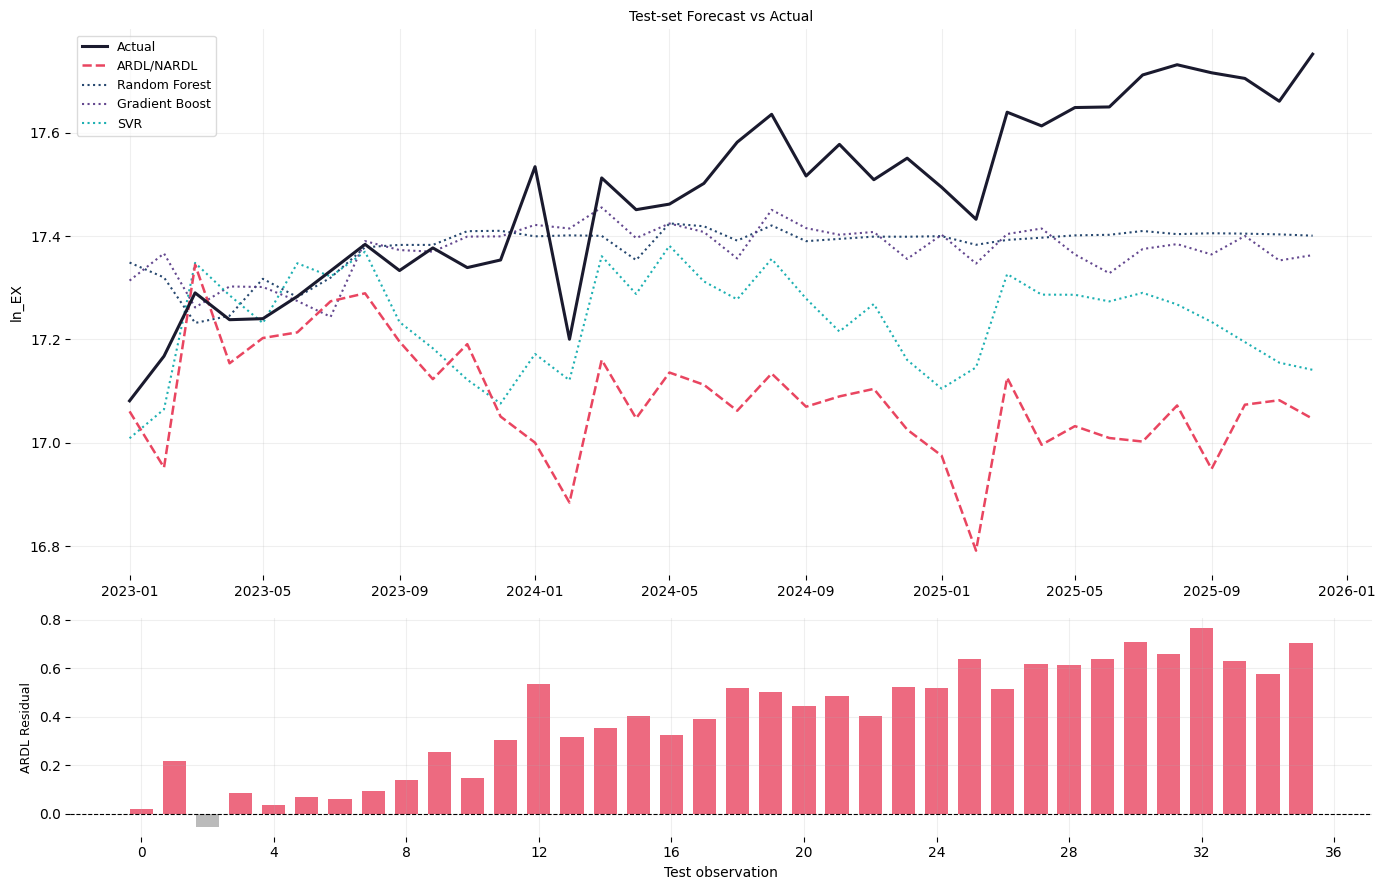

  Saved → ../results/forecast\forecast_EX.png


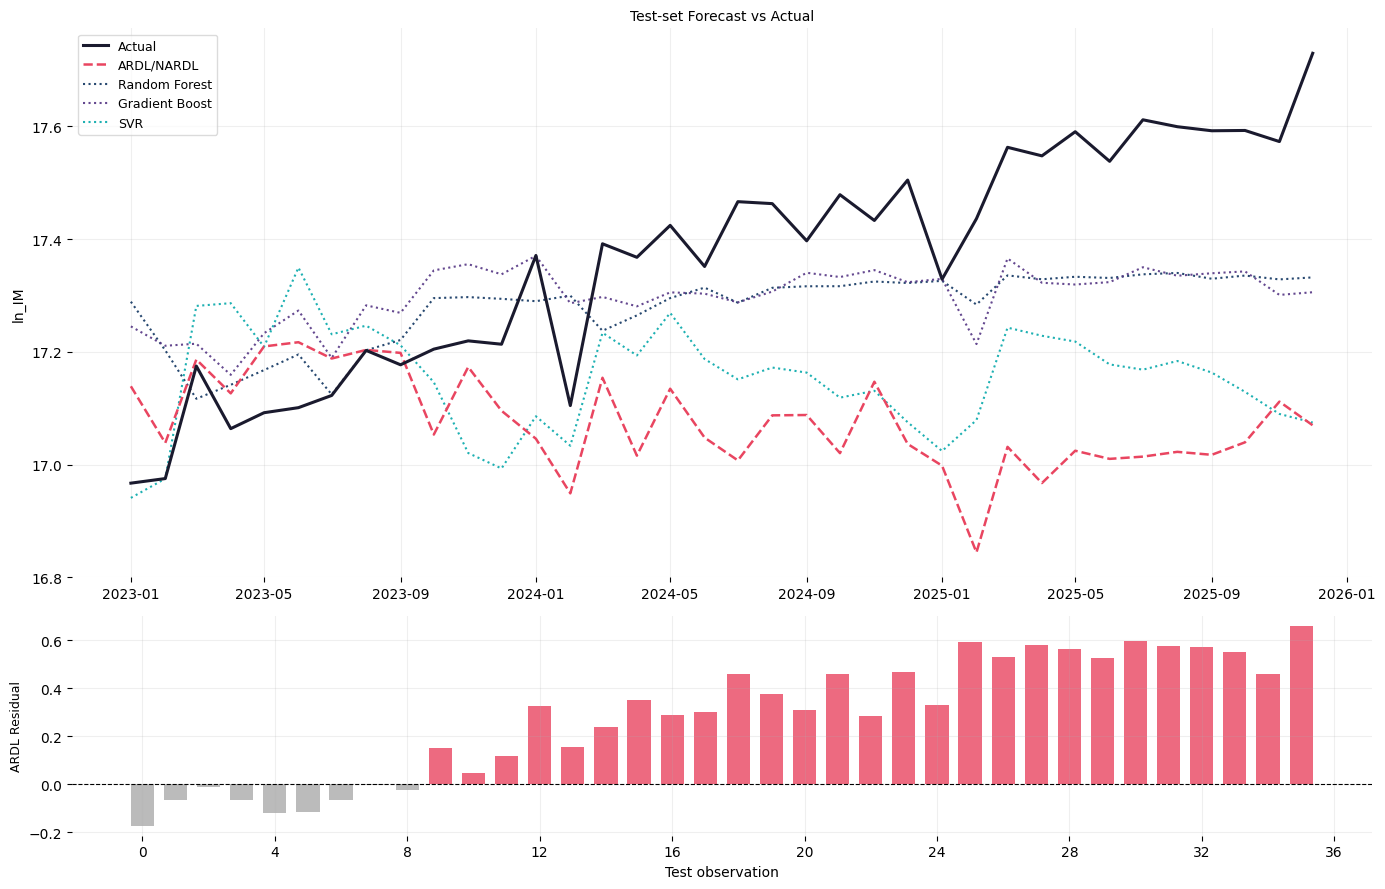

  Saved → ../results/forecast\forecast_IM.png


In [48]:
COLORS = {'Actual':'#1a1a2e','ARDL/NARDL':'#e94560',
          'Random Forest':'#0f3460','Gradient Boost':'#533483','SVR':'#05a8aa'}

for mk in MODELS:
    dep = MODELS[mk]['dep']
    ar  = ardl_results[mk]
    ml  = ml_results[mk]

    fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                             gridspec_kw={'height_ratios':[2.5,1]})

    # Top: forecast lines
    ax = axes[0]
    idx = ar['idx_test']
    ax.plot(idx, ar['y_actual_test'], color=COLORS['Actual'],
            lw=2.2, label='Actual', zorder=5)
    ax.plot(idx, ar['y_pred_test'], color=COLORS['ARDL/NARDL'],
            lw=1.8, ls='--', label='ARDL/NARDL', zorder=4)

    for ml_name in ['Random Forest','Gradient Boost','SVR']:
        ml_idx  = ml['idx_test']
        ml_pred = ml['preds'][ml_name]
        n_plot  = min(len(idx), len(ml_idx), len(ml_pred))
        ax.plot(ml_idx[:n_plot], ml_pred[:n_plot],
                color=COLORS[ml_name], lw=1.5, ls=':', label=ml_name, alpha=0.9)

    ax.set_ylabel(dep); ax.legend(fontsize=9, framealpha=0.7)
    ax.grid(alpha=0.2); ax.set_title('Test-set Forecast vs Actual', fontsize=10)

    # --- Bỏ toàn bộ khung đen cho top subplot ---
    for spine in ['top','right','left','bottom']:
        ax.spines[spine].set_visible(False)

    # Bottom: ARDL residuals
    ax2 = axes[1]
    resid = ar['y_actual_test'] - ar['y_pred_test']
    bar_c = [COLORS['ARDL/NARDL'] if r >= 0 else '#aaaaaa' for r in resid]
    ax2.bar(range(len(resid)), resid, color=bar_c, alpha=0.8, width=0.7)
    ax2.axhline(0, color='black', lw=0.8, ls='--')
    ax2.set_xlabel('Test observation'); ax2.set_ylabel('ARDL Residual', fontsize=9)
    ax2.grid(alpha=0.2); ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

    # --- Bỏ toàn bộ khung đen cho bottom subplot ---
    for spine in ['top','right','left','bottom']:
        ax2.spines[spine].set_visible(False)

    plt.tight_layout()
    path = os.path.join(OUT_DIR, f'forecast_{mk}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {path}')

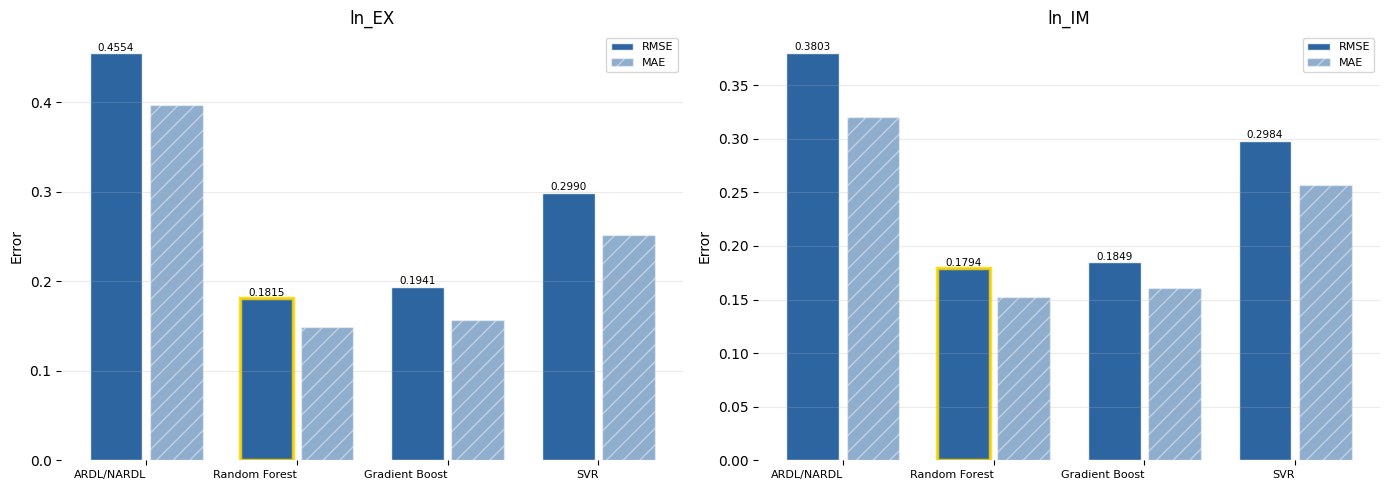

Saved → ../results/forecast\rmse_mae_bar.png


In [47]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(14,5))

for ax, mk in zip(axes, MODELS):
    dep = MODELS[mk]['dep']
    ar  = ardl_results[mk]; ml = ml_results[mk]
    names = ['ARDL/NARDL','Random Forest','Gradient Boost','SVR']
    rmse_v = [ar['metrics']['RMSE']] + [ml['metrics'][n]['RMSE'] for n in names[1:]]
    mae_v  = [ar['metrics']['MAE']]  + [ml['metrics'][n]['MAE']  for n in names[1:]]
    x = np.arange(len(names))
    
    # RMSE bars
    bars = ax.bar(x-0.2, rmse_v, width=0.35, label='RMSE', color=bar_colors, alpha=0.85, edgecolor='white')
    # MAE bars
    ax.bar(x+0.2, mae_v, width=0.35, label='MAE', color=bar_colors, alpha=0.45, edgecolor='white', hatch='//')
    
    # Ghi giá trị lên bar
    for bar, v in zip(bars, rmse_v):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
                f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)
    
    # Highlight bar RMSE thấp nhất
    best = int(np.argmin(rmse_v))
    bars[best].set_edgecolor('gold'); bars[best].set_linewidth(2.5)
    
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=0, ha='right', fontsize=8)
    ax.set_title(dep)
    ax.set_ylabel('Error')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    
    # --- Bỏ toàn bộ khung đen ---
    for spine in ['top','right','left','bottom']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
path = os.path.join(OUT_DIR,'rmse_mae_bar.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

## 8. Feature Importance (Random Forest)

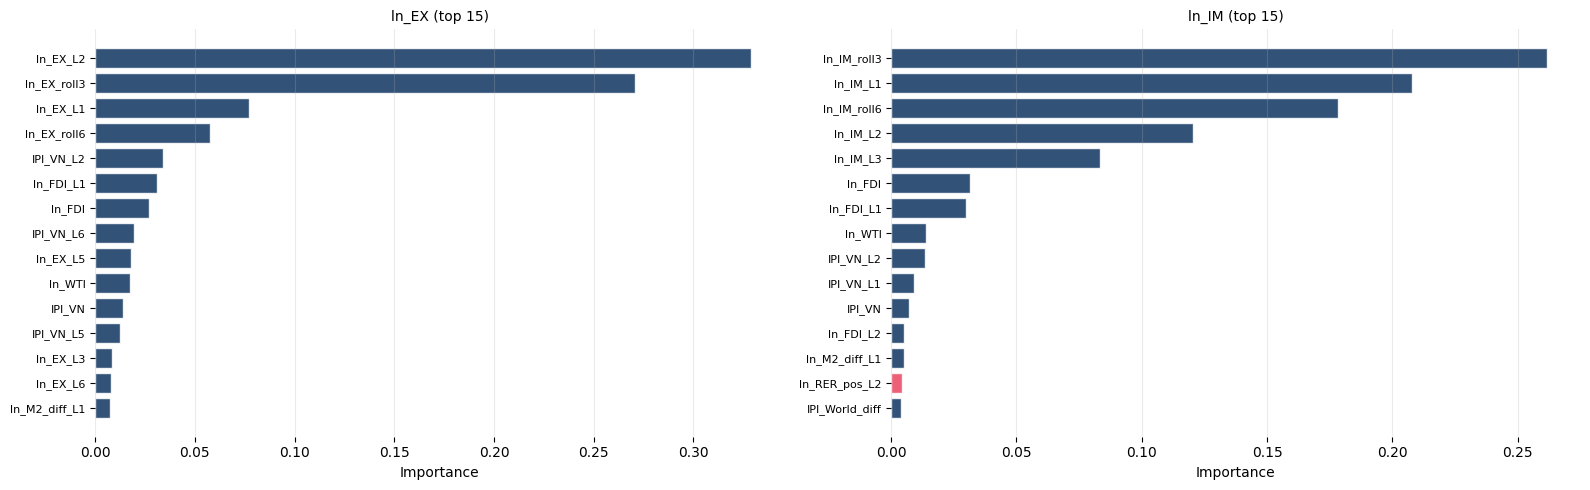

Saved → ../results/forecast\feature_importance_rf.png


In [46]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16,5))
TOP_N = 15
for ax, mk in zip(axes, MODELS):
    dep  = MODELS[mk]['dep']
    ml   = ml_results[mk]
    fi   = ml['preds'].get('Random Forest_fi')
    fcols = ml['feat_cols']
    if fi is None:
        ax.text(0.5,0.5,'N/A',transform=ax.transAxes,ha='center')
        continue
    order   = np.argsort(fi)[::-1][:TOP_N]
    top_fi  = fi[order]
    top_n   = [fcols[i] for i in order]
    bar_c   = ['#e94560' if 'RER' in n else '#0f3460' for n in top_n]
    ax.barh(range(len(top_n)), top_fi[::-1], color=bar_c[::-1], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(top_n)))
    ax.set_yticklabels(top_n[::-1], fontsize=8)
    ax.set_xlabel('Importance')
    ax.set_title(f'{dep} (top {TOP_N})', fontsize=10)
    ax.grid(axis='x', alpha=0.25)

    # --- Bỏ toàn bộ khung ---
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
path = os.path.join(OUT_DIR,'feature_importance_rf.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

## 9. In-sample Fit (Training Period)

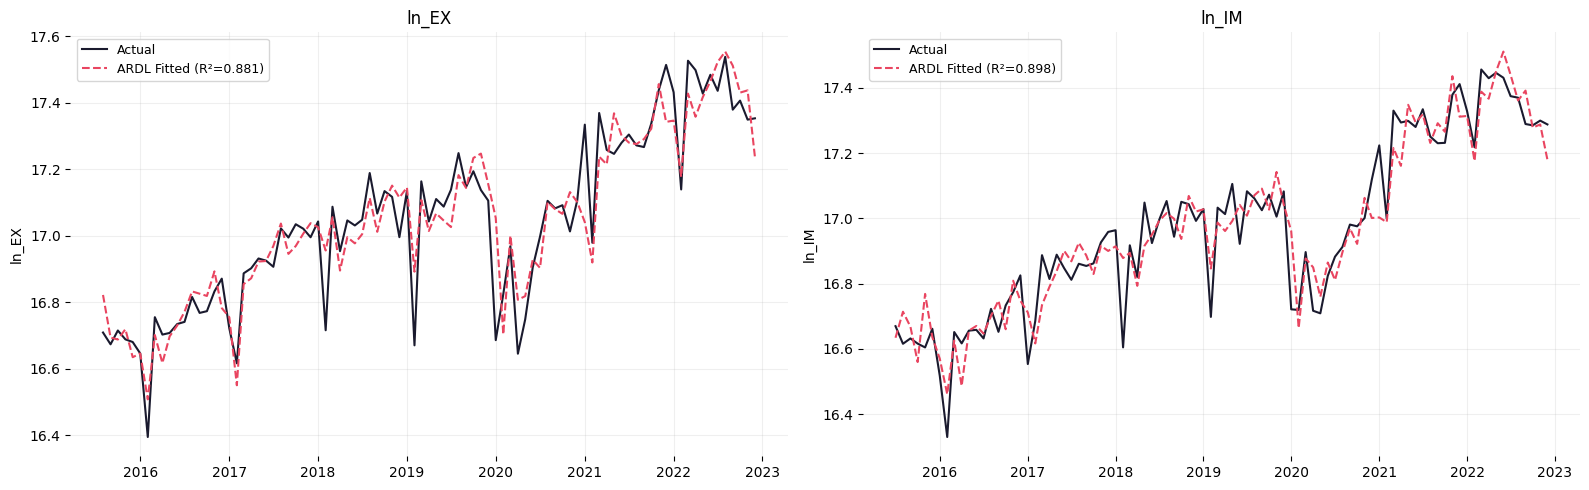

Saved → ../results/forecast\insample_fit.png


In [49]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16,5))

for ax, mk in zip(axes, MODELS):
    dep = MODELS[mk]['dep']; ar = ardl_results[mk]
    ax.plot(ar['idx_train'], ar['y_train'], color='#1a1a2e', lw=1.5, label='Actual')
    ax.plot(ar['idx_train'], ar['fitted_train'], color='#e94560', lw=1.5, ls='--',
            label=f'ARDL Fitted (R²={ar["R2_train"]:.3f})')
    
    ax.set_title(dep)
    ax.set_ylabel(dep)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    
    # --- Bỏ toàn bộ khung đen ---
    for spine in ['top','right','left','bottom']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
path = os.path.join(OUT_DIR,'insample_fit.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

## 10. Export & Verdict

In [41]:
for mk in MODELS:
    dep = MODELS[mk]['dep']
    ar  = ardl_results[mk]; ml = ml_results[mk]
    df_out = pd.DataFrame({'Actual': ar['y_actual_test'],
                           'ARDL_NARDL': ar['y_pred_test']}, index=ar['idx_test'])
    for ml_name in ['Random Forest','Gradient Boost','SVR']:
        ml_ser = pd.Series(ml['preds'][ml_name], index=ml['idx_test'])
        df_out[ml_name.replace(' ','_')] = ml_ser.reindex(ar['idx_test'])
    path = os.path.join(OUT_DIR, f'forecast_{mk}.csv')
    df_out.to_csv(path); print(f'Saved {mk} → {path}')

# Verdict
print('\n' + '='*65)
for mk in MODELS:
    dep = MODELS[mk]['dep']
    ar  = ardl_results[mk]; ml = ml_results[mk]
    all_r = {'ARDL/NARDL': ar['metrics']['RMSE'],
             **{n: ml['metrics'][n]['RMSE'] for n in ['Random Forest','Gradient Boost','SVR']}}
    best  = min(all_r, key=all_r.get)
    print(f'\n{dep}:')
    for n, v in all_r.items():
        mark = ' ← BEST' if n == best else ''
        print(f'  {n:22s}: RMSE = {v:.5f}{mark}')
    ardl_r   = all_r['ARDL/NARDL']
    best_ml  = min(v for k,v in all_r.items() if k != 'ARDL/NARDL')
    pct_diff = (best_ml - ardl_r) / ardl_r * 100
    if pct_diff < -5:   verdict = f'ML outperforms ARDL by {abs(pct_diff):.1f}%'
    elif pct_diff > 5:  verdict = f'ARDL outperforms best ML by {pct_diff:.1f}%'
    else:               verdict = 'ARDL and ML perform comparably'
    print(f'  → {verdict}')

Saved EX → ../results/forecast\forecast_EX.csv
Saved IM → ../results/forecast\forecast_IM.csv


ln_EX:
  ARDL/NARDL            : RMSE = 0.45536
  Random Forest         : RMSE = 0.18153 ← BEST
  Gradient Boost        : RMSE = 0.19412
  SVR                   : RMSE = 0.29899
  → ML outperforms ARDL by 60.1%

ln_IM:
  ARDL/NARDL            : RMSE = 0.38035
  Random Forest         : RMSE = 0.17944 ← BEST
  Gradient Boost        : RMSE = 0.18486
  SVR                   : RMSE = 0.29839
  → ML outperforms ARDL by 52.8%
